Exploratory Data Analysis of TATA COFFEE stock data

Collect Data
      ↓
Load Data
      ↓
Check Structure
      ↓
Missing Value Analysis
      ↓
Descriptive Statistics
      ↓
Data Visualization
      ↓
Outlier Detection
      ↓
Correlation Analysis
      ↓
Understand Data
      ↓
Build Model

Install Required Libraries
Description

Install Yahoo Finance package to download stock data

In [1]:
!pip install yfinance

Import Libraries
Description

Import all libraries required for EDA.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

Download Stock Data
Description

Download Tata Consumer stock data (Tata Coffee).

In [3]:
stk_data = yf.download(
    "TATACONSUM.NS",
    start="2021-06-01",
    end="2022-01-06"
)

/tmp/ipykernel_4381/2521064725.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stk_data = yf.download(
[*********************100%***********************]  1 of 1 completed


Remove Multi-Level Columns
Description

yfinance creates MultiIndex columns. Convert them into normal columns.

In [4]:
stk_data.columns = stk_data.columns.get_level_values(0)

View First 5 Records
Description

Check whether data loaded correctly.

In [5]:
stk_data.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2021-06-01,635.153992,636.537262,626.568251,635.153992,2355484
2021-06-02,642.547241,643.692018,629.764063,634.867785,3021421
2021-06-03,648.700317,651.562231,642.261013,644.884433,2485855
2021-06-04,655.330383,658.192296,643.930418,649.511125,2398771
2021-06-07,667.732117,674.457602,655.664358,658.240092,3511853


Dataset Shape
Description

Check number of rows and columns.

In [6]:
stk_data.shape

(151, 5)

Check Missing Values
Description

Find null values.

In [7]:
stk_data.isnull().sum()

,0
Price,
Close,0
High,0
Low,0
Open,0
Volume,0


Statistical Summary
Description

Generate descriptive statistics.

In [8]:
stk_data.describe()

Price,Close,High,Low,Open,Volume
count,151.000000,151.000000,151.000000,151.000000,1.510000e+02
mean,756.625163,765.157207,748.405931,757.820237,2.061955e+06
std,49.761097,50.810093,49.833731,50.896445,1.257744e+06
min,635.153992,636.537262,626.568251,634.867785,1.758370e+05
25%,725.474274,733.389647,717.415093,727.369250,1.409741e+06
50%,743.703552,754.928826,735.596295,748.596605,1.747911e+06
75%,799.782318,807.673666,789.516410,801.077546,2.353983e+06
max,846.314758,852.934772,841.997332,849.097056,7.956492e+06


Assign Dataset
Description

Create working dataset variable.

In [9]:
dataset = stk_data

Create Descriptive Class
Description

Separate Quantitative and Qualitative columns.

In [10]:
class Descriptive():

    def __init__(self):
        pass

    def segreQuanQual(self,dataset):

        quantative=[]
        qualtative=[]

        for i in dataset.columns:

            if dataset[i].dtype=="object":
                qualtative.append(i)
            else:
                quantative.append(i)

        return quantative,qualtative

Create Object
Description

Create class object.

In [11]:
obj=Descriptive()

Separate Columns
Description

Identify numerical and categorical columns.

In [12]:
quantative,qualtative=obj.segreQuanQual(dataset)

print("Quantitative:",quantative)
print("Qualitative:",qualtative)

Quantitative: ['Close', 'High', 'Low', 'Open', 'Volume']
Qualitative: []


Detailed Descriptive Analysis
Description

Create complete descriptive statistics table.

In [13]:
def descriptive_analysis(dataset,quantative):

    des_data=pd.DataFrame(
        index=[
            "Null_Count",
            "Mean",
            "Median",
            "Mode",
            "Std",
            "Min",
            "25%",
            "50%",
            "75%",
            "Max"
        ],
        columns=quantative
    )

    for i in quantative:

        des_data[i]["Null_Count"]=dataset[i].isnull().sum()
        des_data[i]["Mean"]=dataset[i].mean()
        des_data[i]["Median"]=dataset[i].median()
        des_data[i]["Mode"]=dataset[i].mode()[0]
        des_data[i]["Std"]=dataset[i].std()
        des_data[i]["Min"]=dataset[i].min()
        des_data[i]["25%"]=dataset[i].quantile(.25)
        des_data[i]["50%"]=dataset[i].quantile(.50)
        des_data[i]["75%"]=dataset[i].quantile(.75)
        des_data[i]["Max"]=dataset[i].max()

    return des_data

Generate Descriptive Table

In [14]:
des_data=descriptive_analysis(dataset,quantative)

des_data

/tmp/ipykernel_4381/645390022.py:21: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  des_data[i]["Null_Count"]=dataset[i].isnull().sum()
/tmp/ipykernel_4381/645390022.py:22: FutureWarning: ChainedAssignmentError: behaviour will change in panda

,Close,High,Low,Open,Volume
Null_Count,0,0,0,0,0
Mean,756.625163,765.157207,748.405931,757.820237,2061954.523179
Median,743.703552,754.928826,735.596295,748.596605,1747911.0
Mode,785.534851,636.537262,626.568251,634.867785,175837
Std,49.761097,50.810093,49.833731,50.896445,1257743.69521
Min,635.153992,636.537262,626.568251,634.867785,175837
25%,725.474274,733.389647,717.415093,727.36925,1409741.0
50%,743.703552,754.928826,735.596295,748.596605,1747911.0
75%,799.782318,807.673666,789.51641,801.077546,2353983.0
Max,846.314758,852.934772,841.997332,849.097056,7956492


View Low Price Statistics
Description

Display Low column statistics.

In [15]:
des_data["Low"]

,Low
Null_Count,0
Mean,748.405931
Median,735.596295
Mode,626.568251
Std,49.833731
Min,626.568251
25%,717.415093
50%,735.596295
75%,789.51641
Max,841.997332


View High Price Statistics

In [16]:
des_data["High"]

,High
Null_Count,0
Mean,765.157207
Median,754.928826
Mode,636.537262
Std,50.810093
Min,636.537262
25%,733.389647
50%,754.928826
75%,807.673666
Max,852.934772


Histogram
Description

Visualize data distribution.

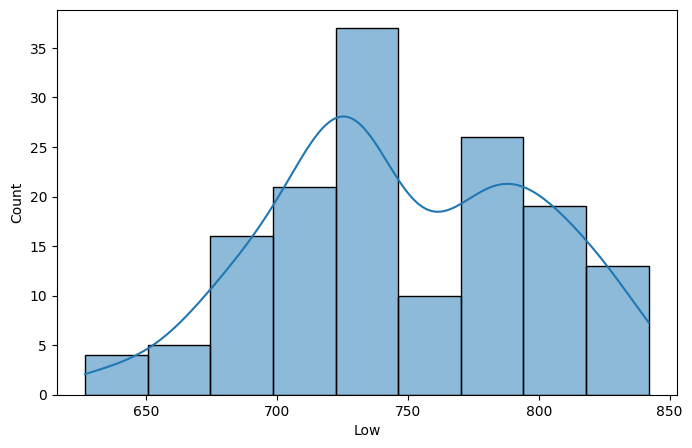

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(dataset["Low"],kde=True)
plt.show()

| Sl. No | Observation                                                            | Interpretation                                                          |
| ------ | ---------------------------------------------------------------------- | ----------------------------------------------------------------------- |
| 1      | The histogram represents the distribution of the **Low stock price**.  | It shows how frequently different Low prices occurred.                  |
| 2      | The X-axis contains Low price values.                                  | Prices range approximately from **₹630 to ₹845**.                       |
| 3      | The Y-axis represents frequency (count).                               | It indicates the number of trading days for each price range.           |
| 4      | The highest frequency occurs around **₹720–₹740**.                     | Most trading days had Low prices in this range.                         |
| 5      | Most observations are concentrated between **₹700 and ₹800**.          | The stock price remained stable within this range for most days.        |
| 6      | Very few observations are below **₹650**.                              | Extremely low prices occurred rarely.                                   |
| 7      | Very few observations are above **₹830**.                              | Extremely high Low prices occurred rarely.                              |
| 8      | The KDE curve shows the overall distribution pattern.                  | It helps visualize where data is concentrated.                          |
| 9      | The distribution appears moderately spread.                            | There is variability in the stock's Low price over time.                |
| 10     | No extreme skewness is visible.                                        | The stock prices are fairly balanced around the central range.          |
| 11     | The data does not appear to contain many unusual values.               | Most prices follow a common pattern.                                    |
| 12     | The stock's Low price generally fluctuated within a predictable range. | Indicates relatively stable market behavior during the selected period. |


The histogram shows that the Low price of TATA COFFEE was mostly concentrated between ₹700 and ₹800, with the highest frequency around ₹730. Very few observations occurred at the extreme ends, indicating that the stock remained relatively stable during the analyzed period.

Box Plot
Description

Detect outliers visually.

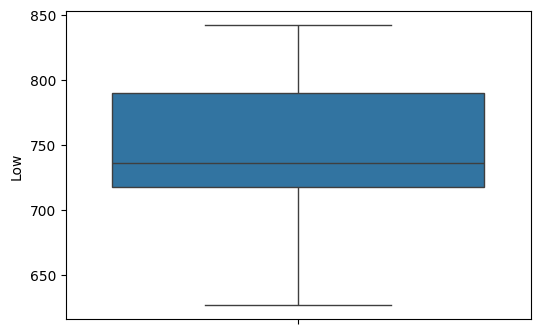

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(y=dataset["Low"])
plt.show()

| Sl. No | Observation                                                   | Interpretation                                              |
| ------ | ------------------------------------------------------------- | ----------------------------------------------------------- |
| 1      | The box plot represents the **Low stock price** distribution. | It summarizes the spread of the data using quartiles.       |
| 2      | The middle line inside the box is the **Median (Q2)**.        | Median Low price is approximately **₹735**.                 |
| 3      | The bottom of the box represents **Q1 (25th percentile)**.    | About 25% of Low prices are below **₹718**.                 |
| 4      | The top of the box represents **Q3 (75th percentile)**.       | About 75% of Low prices are below **₹790**.                 |
| 5      | The box represents the **Interquartile Range (IQR)**.         | The middle 50% of Low prices lie between **₹718 and ₹790**. |
| 6      | The lower whisker extends to approximately **₹627**.          | This is the minimum Low price observed.                     |
| 7      | The upper whisker extends to approximately **₹842**.          | This is the maximum Low price observed.                     |
| 8      | No individual points are visible outside the whiskers.        | No significant outliers are detected.                       |
| 9      | The median is closer to the lower part of the box.            | Slight variation exists in the upper range of prices.       |
| 10     | The spread between Q1 and Q3 is moderate.                     | Stock prices show normal fluctuations.                      |
| 11     | The whiskers are relatively balanced.                         | Data distribution is fairly symmetric.                      |
| 12     | Most Low prices are concentrated between **₹718 and ₹790**.   | The stock remained stable during most trading days.         |


| Component    | Meaning                                      |
| ------------ | -------------------------------------------- |
| Minimum      | Lowest observed value (≈ ₹627)               |
| Q1 (25%)     | 25% of values fall below this point (≈ ₹718) |
| Median (50%) | Middle value of the dataset (≈ ₹735)         |
| Q3 (75%)     | 75% of values fall below this point (≈ ₹790) |
| Maximum      | Highest observed value (≈ ₹842)              |
| IQR          | Q3 − Q1 (spread of middle 50% data)          |


The box plot indicates that the Low prices of TATA COFFEE are fairly distributed with no significant outliers. The median Low price is around ₹735, and the majority of stock prices are concentrated between ₹718 and ₹790. The stock exhibited moderate variability and relatively stable price behavior during the analyzed period.

Line Plot
Description

Visualize stock trend over time

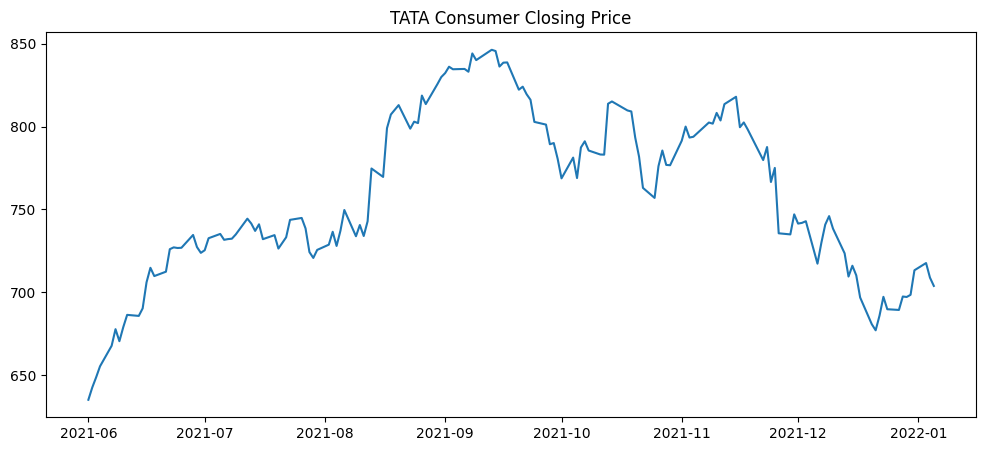

In [19]:
plt.figure(figsize=(12,5))

plt.plot(dataset["Close"])

plt.title("TATA Consumer Closing Price")

plt.show()

Line Plot (Closing Price) – Observation Table

| Sl. No | Observation                                                                               | Interpretation                                          |
| ------ | ----------------------------------------------------------------------------------------- | ------------------------------------------------------- |
| 1      | The graph shows the **Closing Price trend** of TATA Consumer/TATA Coffee stock over time. | It helps analyze stock movement across different dates. |
| 2      | The stock started around **₹635** in June 2021.                                           | Initial closing price was relatively low.               |
| 3      | A steady upward trend is observed from June to September 2021.                            | Stock price increased consistently during this period.  |
| 4      | The highest closing price occurred around September 2021.                                 | Peak price reached approximately **₹845**.              |
| 5      | The stock experienced a strong bullish trend between August and September.                | Investor confidence was likely high.                    |
| 6      | After September, the stock price started declining.                                       | A downward correction phase began.                      |
| 7      | Significant fluctuations are visible during October and November.                         | The market experienced higher volatility.               |
| 8      | Another short-term rise occurred in November 2021.                                        | Stock recovered temporarily before declining again.     |
| 9      | A sharp decline is visible during December 2021.                                          | Selling pressure increased during this period.          |
| 10     | The lowest closing prices toward the end of the period are around **₹680–₹700**.          | Stock lost value compared to its peak.                  |
| 11     | The stock ended around **₹710–₹720** in January 2022.                                     | Final price remained higher than the starting price.    |
| 12     | Overall, the stock shows both upward and downward movements.                              | Indicates normal market fluctuations.                   |


Trend Analysis Summary

| Period                        | Trend                   |
| ----------------------------- | ----------------------- |
| June 2021 – July 2021         | Upward Trend 📈         |
| July 2021 – August 2021       | Stable Growth 📈        |
| August 2021 – September 2021  | Strong Bullish Trend 📈 |
| September 2021 – October 2021 | Downward Correction 📉  |
| October 2021 – November 2021  | Fluctuating Trend ↕️    |
| November 2021 – December 2021 | Declining Trend 📉      |
| December 2021 – January 2022  | Slight Recovery 📈      |

=======

The closing price of TATA COFFEE showed an overall upward movement from June 2021 to September 2021, reaching a peak of approximately ₹845. After the peak, the stock experienced fluctuations and a downward correction, eventually closing around ₹710–₹720 in January 2022. The graph indicates moderate volatility and changing market sentiment during the analyzed period.

Frequency Table Function
Description

Create frequency table.

In [20]:
def freqTable(columnName,dataset):

    frq=pd.DataFrame()

    frq["Unique_Values"]=dataset[columnName].value_counts().index

    frq["Frequency"]=dataset[columnName].value_counts().values

    frq["Relative_Frequency"]=(
        dataset[columnName].value_counts().values
        /len(dataset[columnName])
    )*100

    frq["Cumulative"]=frq["Relative_Frequency"].cumsum()

    return frq

Generate Frequency Table

In [21]:
fh=freqTable("Low",dataset)

fh.head()

,Unique_Values,Frequency,Relative_Frequency,Cumulative
0,626.568251,1,0.662252,0.662252
1,629.764063,1,0.662252,1.324503
2,642.261013,1,0.662252,1.986755
3,643.930418,1,0.662252,2.649007
4,655.664358,1,0.662252,3.311258


| Observation                              | Interpretation                 |
| ---------------------------------------- | ------------------------------ |
| All frequencies are 1                    | No repeated Low prices         |
| Relative frequency ≈ 0.66%               | Each value contributes equally |
| Cumulative frequency increases gradually | Values are unique              |
| No dominant value exists                 | No strong mode present         |
| Stock prices are continuous              | Each day has a different price |


Uses in EDA

| Use                        | Description                     |
| -------------------------- | ------------------------------- |
| Frequency Analysis         | Find repeated values            |
| Mode Identification        | Find most common value          |
| Distribution Understanding | See how values are spread       |
| Duplicate Detection        | Check if values repeat          |
| Probability Analysis       | Calculate occurrence percentage |


Values Appearing Twice




In [22]:
fhs=fh[fh["Frequency"]==2]["Unique_Values"]

fhs

,Unique_Values


This code searches for values that appear exactly 2 times in the Low column.

Step-by-step:

| Part                 | Meaning                          |
| -------------------- | -------------------------------- |
| `fh["Frequency"]==2` | Select rows where frequency is 2 |
| `fh[...]`            | Filter those rows                |
| `["Unique_Values"]`  | Show only the values             |
| `fhs`                | Store the result                 |

------

There are no Low price values that appear exactly 2 times.

-----

| Low Price | Frequency |
| --------- | --------- |
| 626.56    | 1         |
| 629.76    | 1         |
| 642.26    | 1         |
| 643.93    | 1         |
| 655.66    | 1         |





Percentile Calculation
Description

Calculate 99th percentile.

In [23]:
np.percentile(dataset["Low"],99)

np.float64(836.5764962100604)

What is Percentile?

A percentile tells us what percentage of data lies below a particular value.

Example
50th Percentile = Median
75th Percentile = 75% of values are below this value
99th Percentile = 99% of values are below this value


Meaning of Your Result

| Metric          | Value   |
| --------------- | ------- |
| Percentile      | 99th    |
| Low Price Value | ₹836.58 |

=========

Interpretation

99% of the Low stock prices are less than or equal to ₹836.58.

Only:

1% of the Low prices are above ₹836.58

---------------

Visual Understanding

stock records:

151 Records

Then:

99% of 151 ≈ 149.5

Meaning:

About 149–150 records have Low prices ≤ ₹836.58
Only 1–2 records have Low prices > ₹836.58

=========

The 99th percentile of the Low stock price is ₹836.58. This means that 99% of the observed Low prices are less than or equal to ₹836.58, while only 1% of the observations are greater than this value. It helps identify the upper boundary of the stock price distribution and detect extreme values.



Correlation Matrix
Description

Find relationships among variables.

In [24]:
dataset.corr()

Price,Close,High,Low,Open,Volume
Price,,,,,
Close,1.000000,0.991227,0.993459,0.979955,-0.082780
High,0.991227,1.000000,0.992008,0.992139,-0.070309
Low,0.993459,0.992008,1.000000,0.989629,-0.131173
Open,0.979955,0.992139,0.989629,1.000000,-0.139784
Volume,-0.082780,-0.070309,-0.131173,-0.139784,1.000000


Correlation Matrix – Explanation

A Correlation Matrix shows the relationship between variables.

Correlation values range from:

| Correlation Value | Meaning                       |
| ----------------- | ----------------------------- |
| +1                | Perfect Positive Correlation  |
| +0.7 to +0.99     | Strong Positive Correlation   |
| +0.3 to +0.69     | Moderate Positive Correlation |
| 0                 | No Relationship               |
| -0.3 to -0.69     | Moderate Negative Correlation |
| -0.7 to -0.99     | Strong Negative Correlation   |
| -1                | Perfect Negative Correlation  |

===========

| Sl. No | Observation                                  | Interpretation                                                |
| ------ | -------------------------------------------- | ------------------------------------------------------------- |
| 1      | Close and High = 0.991                       | Very strong positive relationship.                            |
| 2      | Close and Low = 0.993                        | Strongest positive relationship.                              |
| 3      | Close and Open = 0.980                       | Strong positive relationship.                                 |
| 4      | High and Low = 0.992                         | Move almost together.                                         |
| 5      | High and Open = 0.992                        | Strong relationship exists.                                   |
| 6      | Low and Open = 0.990                         | Strong positive correlation.                                  |
| 7      | Volume and Close = -0.083                    | Very weak negative relationship.                              |
| 8      | Volume and High = -0.070                     | Almost no relationship.                                       |
| 9      | Volume and Low = -0.131                      | Weak negative relationship.                                   |
| 10     | Volume and Open = -0.140                     | Weak negative relationship.                                   |
| 11     | Price variables are highly correlated.       | Prices move together in the same direction.                   |
| 12     | Volume has very low correlation with prices. | Trading volume does not strongly affect stock price movement. |

===========================

The correlation matrix shows a very strong positive relationship among Open, High, Low, and Close prices, with correlation values greater than 0.98. This indicates that all price variables move together. The Volume variable has a weak negative correlation with price variables, suggesting that trading volume has minimal influence on stock price movements in the analyzed period.

Correlation Heatmap
Description

Visual representation of correlation.

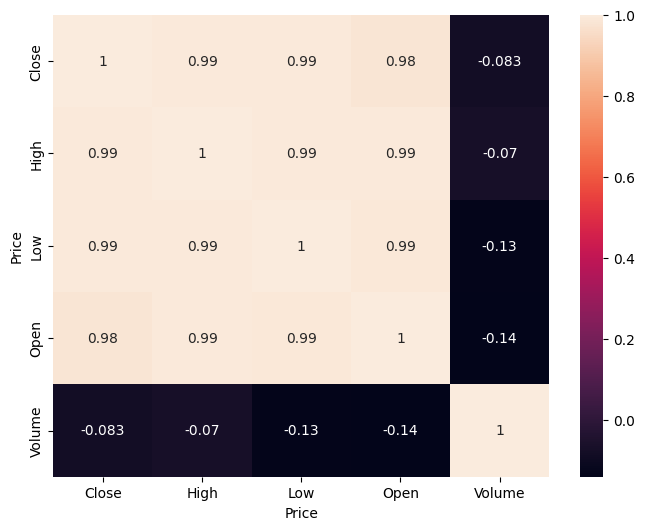

In [25]:
plt.figure(figsize=(8,6))

sns.heatmap(
    dataset.corr(),
    annot=True
)

plt.show()

Correlation Heatmap – Explanation

A Correlation Heatmap is a visual representation of the correlation matrix.

It helps us quickly identify:

Strong relationships
Weak relationships
Positive correlations
Negative correlations

Color Interpretation
| Color             | Meaning                          |
| ----------------- | -------------------------------- |
| Light Color       | Strong Positive Correlation (+1) |
| Dark Color        | Weak/Negative Correlation        |
| Value close to 1  | Strong Relationship              |
| Value close to 0  | No Relationship                  |
| Value close to -1 | Strong Negative Relationship     |

========

Observation table:

| Sl. No | Observation                                  | Interpretation                                      |
| ------ | -------------------------------------------- | --------------------------------------------------- |
| 1      | Close vs High = 0.99                         | Very strong positive correlation.                   |
| 2      | Close vs Low = 0.99                          | Very strong positive correlation.                   |
| 3      | Close vs Open = 0.98                         | Strong positive correlation.                        |
| 4      | High vs Low = 0.99                           | High and Low prices move together.                  |
| 5      | High vs Open = 0.99                          | Strong relationship exists.                         |
| 6      | Low vs Open = 0.99                           | Strong positive relationship.                       |
| 7      | Volume vs Close = -0.083                     | Very weak negative correlation.                     |
| 8      | Volume vs High = -0.070                      | Almost no relationship.                             |
| 9      | Volume vs Low = -0.13                        | Weak negative relationship.                         |
| 10     | Volume vs Open = -0.14                       | Weak negative relationship.                         |
| 11     | Diagonal values are 1.00                     | Every variable is perfectly correlated with itself. |
| 12     | Price variables have light-colored cells.    | Indicates strong positive correlation among prices. |
| 13     | Volume column appears darker.                | Indicates weak correlation with stock prices.       |
| 14     | No strong negative correlations are present. | Variables generally move together.                  |


Variable-Wise InterpretationVariable-Wise Interpretation

| Variables                | Correlation    | Meaning                                        |
| ------------------------ | -------------- | ---------------------------------------------- |
| Close ↔ High             | 0.99           | When Close increases, High also increases.     |
| Close ↔ Low              | 0.99           | Strong relationship between Close and Low.     |
| Close ↔ Open             | 0.98           | Opening and Closing prices move together.      |
| High ↔ Low               | 0.99           | Daily High and Low prices are closely related. |
| Open ↔ High              | 0.99           | Opening price influences daily High.           |
| Volume ↔ Price Variables | -0.07 to -0.14 | Very weak negative relationship.               |
==============

The correlation heatmap reveals a very strong positive relationship among Open, High, Low, and Close prices, with correlation values close to 1. This indicates that these stock price variables move together. Volume has a weak negative correlation with all price variables, suggesting that trading volume has minimal influence on price movement during the analyzed period.